In [36]:
import duckdb

conn = duckdb.connect("../credit_risk_warehouse.db")
print("⚡ Successfully reconnected to the analytical data warehouse!")

⚡ Successfully reconnected to the analytical data warehouse!


In [37]:
risk_analysis_df = conn.execute("""
    SELECT 
        CASE 
            WHEN AMT_INCOME_TOTAL < 100000 THEN 'Low Income (<100k)'
            WHEN AMT_INCOME_TOTAL BETWEEN 100000 AND 200000 THEN 'Medium Income (100k-200k)'
            ELSE 'High Income (>200k)'
        -- AS creates a clear custom header name for our bucketed group column
        END AS income_segment,
        
        COUNT(*) AS total_applicants,
        SUM(TARGET) AS total_defaulters,
        
        -- Calculating the mathematical percentage rate of defaults per group
        ROUND(AVG(TARGET) * 100, 2) AS default_rate_percentage

    FROM mart_applicant_features
    GROUP BY income_segment
    ORDER BY default_rate_percentage DESC;
""").df()

# Display the resulting data table matrix on the screen
risk_analysis_df

,income_segment,total_applicants,total_defaulters,default_rate_percentage
0,Medium Income (100k-200k),155898,13326.0,8.55
1,Low Income (<100k),63698,5225.0,8.20
2,High Income (>200k),87915,6274.0,7.14


In [38]:
# Pulling raw columns directly from your analytical data warehouse mart
df_plots = conn.execute("""
    SELECT TARGET, credit_income_ratio 
    FROM mart_applicant_features
""").df()

In [44]:
ml_data = df_plots.copy()  # Create a copy of the DataFrame for further analysis

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Change 'df' below to match whatever variable name you used to load your dataset!
active_df = df_plots

# Set the visualization style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ==========================================
# PLOT 1: TARGET IMBALANCE
# ==========================================
sns.countplot(
    x='TARGET', 
    data=active_df, 
    ax=axes[0], 
    hue ='TARGET'
    palette='Blues_d'
    legend = False
)
axes[0].set_title('Target Class Imbalance Audit', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Application Status (0 = Repaid, 1 = Default)', fontsize=12)
axes[0].set_ylabel('Total Applications Count', fontsize=12)

total = len(active_df)
for p in axes[0].patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    axes[0].annotate(percentage, (p.get_x() + 0.3, p.get_height() + 5000), fontsize=12, fontweight='bold')

# ==========================================
# PLOT 2: BEFORE CORRECTION
# ==========================================
sns.kdeplot(
    active_df['credit_income_ratio'], 
    ax=axes[1], 
    color='crimson', 
    fill=True
)
axes[1].set_title('Original Skewed Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Raw Credit-to-Income Ratio', fontsize=12)

# ==========================================
# PLOT 3: AFTER CORRECTION
# ==========================================
# Apply log transformation to handle high-leverage outliers gracefully
active_df['log_credit_income_ratio'] = np.log1p(active_df['credit_income_ratio'])

sns.kdeplot(
    active_df['log_credit_income_ratio'], 
    ax=axes[2], 
    color='teal', 
    fill=True
)
axes[2].set_title('Normalized Distribution (Log Transformed)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Log(Credit-to-Income Ratio + 1)', fontsize=12)

plt.tight_layout()
plt.show()

SyntaxError: invalid syntax. Perhaps you forgot a comma? (212904091.py, line 19)

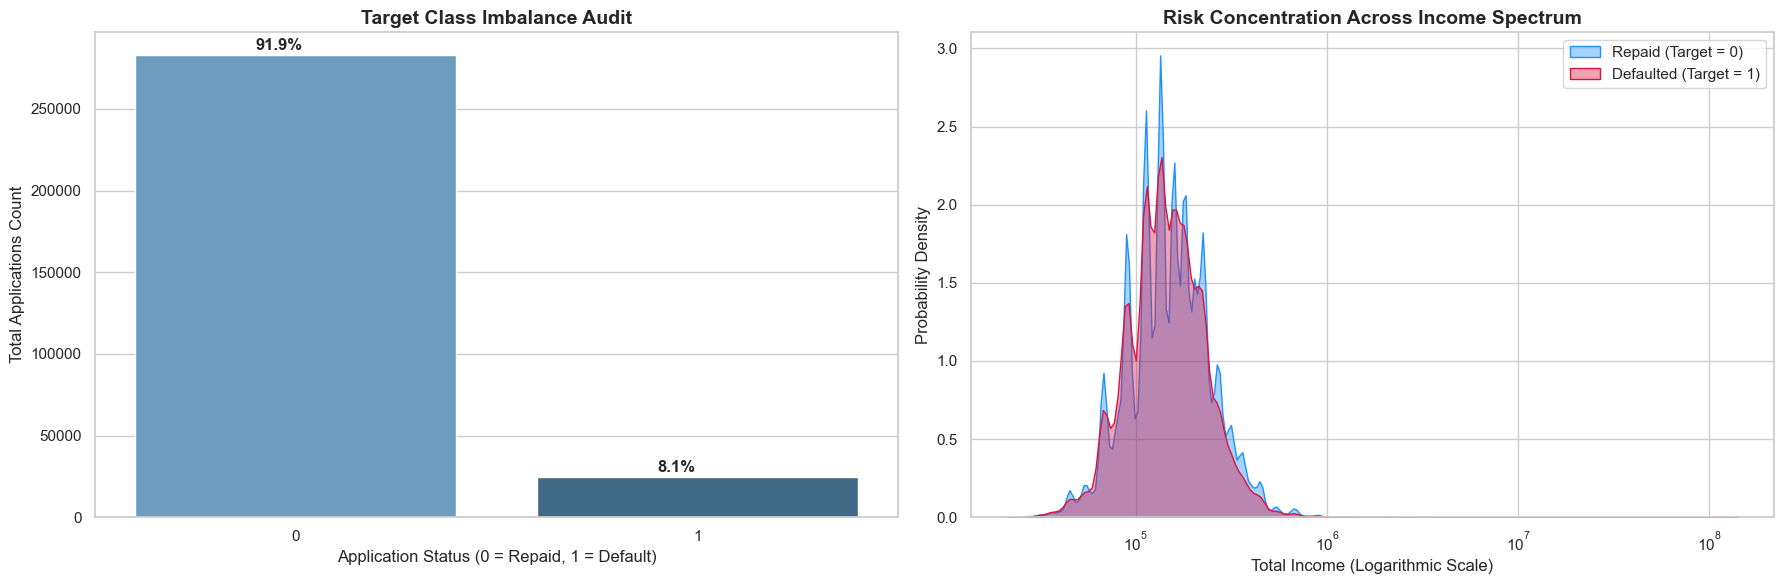

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Set up a clean, professional canvas with two side-by-side plots
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ==========================================================
# PLOT 1: THE TARGET CLASS IMBALANCE AUDIT
# ==========================================================
sns.countplot(
    x='TARGET', 
    data=ml_data, 
    hue='TARGET',  # Sets colors per category cleanly
    palette='Blues_d',
    legend=False,
    ax=axes[0]
)

# Add dynamic percentage text labels on top of each bar
total_applicants = len(ml_data)
for p in axes[0].patches:
    percentage = f'{100 * p.get_height() / total_applicants:.1f}%'
    axes[0].annotate(
        percentage, 
        (p.get_x() + 0.3, p.get_height() + (total_applicants * 0.01)), 
        fontsize=12, 
        fontweight='bold'
    )

axes[0].set_title('Target Class Imbalance Audit', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Application Status (0 = Repaid, 1 = Default)', fontsize=12)
axes[0].set_ylabel('Total Applications Count', fontsize=12)

# ==========================================================
# PLOT 2: RISK CONCENTRATION ACROSS INCOME SAMPLES
# ==========================================================
sns.kdeplot(
    data=ml_data[ml_data['TARGET'] == 0],
    x='AMT_INCOME_TOTAL',
    label='Repaid (Target = 0)',
    fill=True,
    color='dodgerblue',
    alpha=0.4,
    ax=axes[1],
    log_scale=True  # Mathematically scales extreme high income outliers
)

sns.kdeplot(
    data=ml_data[ml_data['TARGET'] == 1],
    x='AMT_INCOME_TOTAL',
    label='Defaulted (Target = 1)',
    fill=True,
    color='crimson',
    alpha=0.4,
    ax=axes[1],
    log_scale=True
)

axes[1].set_title('Risk Concentration Across Income Spectrum', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total Income (Logarithmic Scale)', fontsize=12)
axes[1].set_ylabel('Probability Density', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

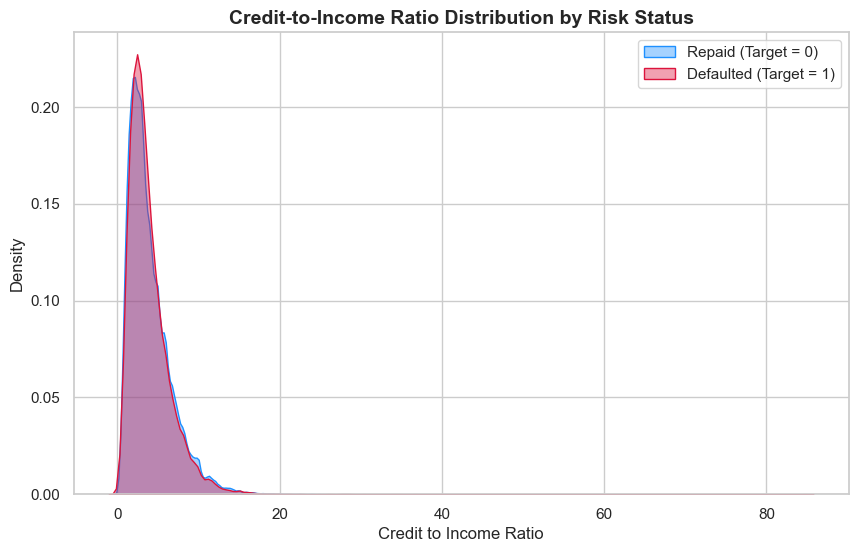

In [48]:
plt.figure(figsize=(10, 6))

# Plotting the engineered credit_income_ratio feature before any scaling
sns.kdeplot(
    data=ml_data[ml_data['TARGET'] == 0],
    x='credit_income_ratio',
    label='Repaid (Target = 0)',
    fill=True,
    color='dodgerblue',
    alpha=0.4
)

sns.kdeplot(
    data=ml_data[ml_data['TARGET'] == 1],
    x='credit_income_ratio',
    label='Defaulted (Target = 1)',
    fill=True,
    color='crimson',
    alpha=0.4
)

plt.title('Credit-to-Income Ratio Distribution by Risk Status', fontsize=14, fontweight='bold')
plt.xlabel('Credit to Income Ratio', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.show()

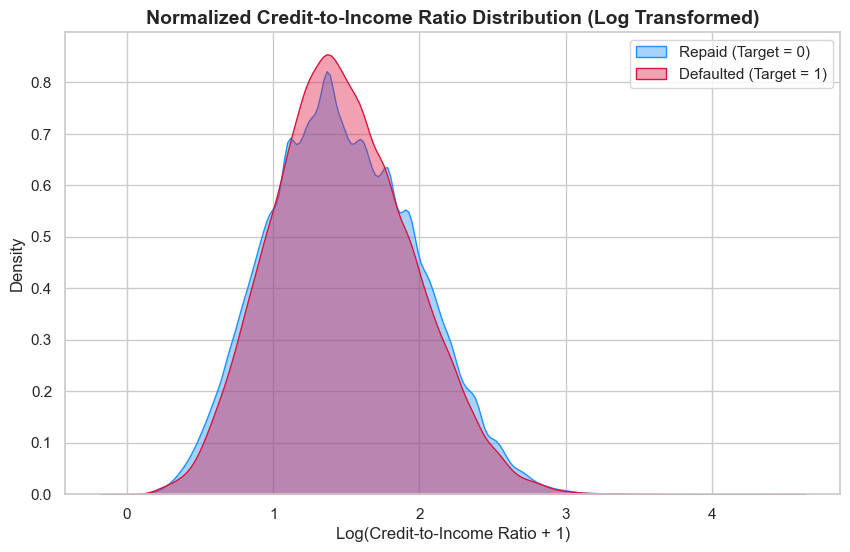

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 6))

# Apply np.log1p (log base e of x + 1) to compress the extreme tail
ml_data['log_credit_income_ratio'] = np.log1p(ml_data['credit_income_ratio'])

# Plot the newly transformed normalized curve
sns.kdeplot(
    data=ml_data[ml_data['TARGET'] == 0],
    x='log_credit_income_ratio',
    label='Repaid (Target = 0)',
    fill=True,
    color='dodgerblue',
    alpha=0.4
)

sns.kdeplot(
    data=ml_data[ml_data['TARGET'] == 1],
    x='log_credit_income_ratio',
    label='Defaulted (Target = 1)',
    fill=True,
    color='crimson',
    alpha=0.4
)

plt.title('Normalized Credit-to-Income Ratio Distribution (Log Transformed)', fontsize=14, fontweight='bold')
plt.xlabel('Log(Credit-to-Income Ratio + 1)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.show()

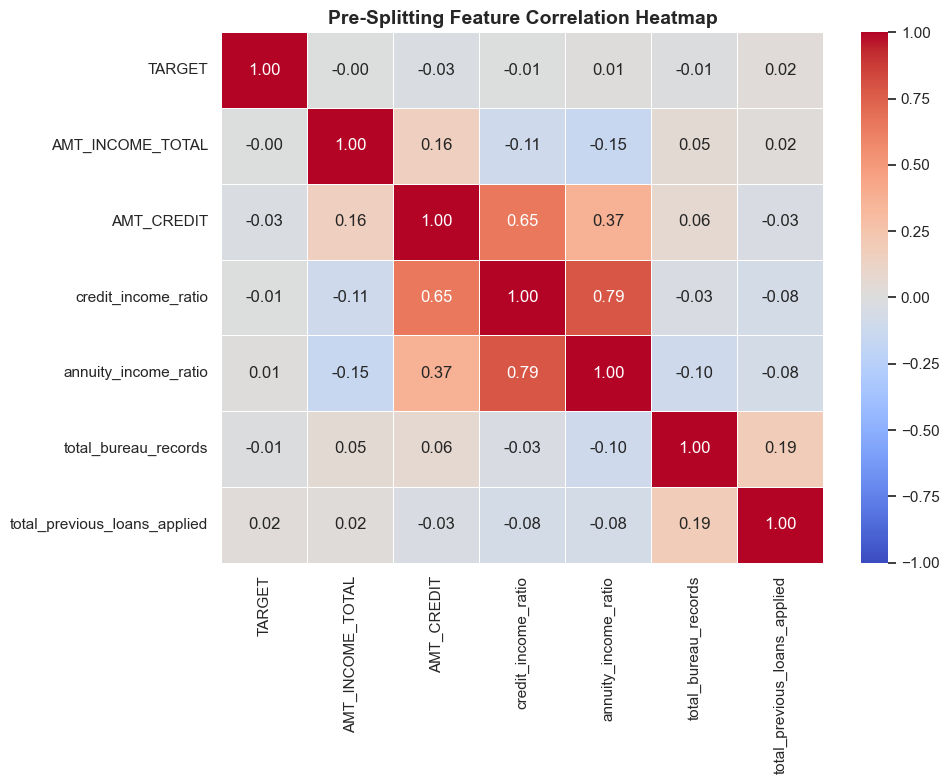

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

# Select your main numeric risk features to check relationships
features_to_audit = [
    'TARGET', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 
    'credit_income_ratio', 'annuity_income_ratio', 
    'total_bureau_records', 'total_previous_loans_applied'
]

# Calculate the Pearson correlation matrix
# create df_for_corr using TARGET from ml_data and features from X if missing in ml_data
df_for_corr = ml_data[['TARGET']].copy() if 'TARGET' in ml_data.columns else pd.DataFrame()
for f in features_to_audit:
    if f == 'TARGET':
        continue
    if f in ml_data.columns:
        df_for_corr[f] = ml_data[f]
    elif 'X' in globals() and f in X.columns:
        df_for_corr[f] = X[f]

# compute correlation matrix
corr_matrix = df_for_corr.corr()

# Draw the heatmap
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5, 
    vmin=-1, 
    vmax=1
)

plt.title('Pre-Splitting Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [52]:
plt.figure(figsize=(10, 5))

# Calculate the percentage of missing values per column
missing_pct = (ml_data.isnull().sum() / len(ml_data)) * 100

# Filter to show only columns that have at least some missing data
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

if not missing_pct.empty:
    sns.barplot(x=missing_pct.values, y=missing_pct.index, palette='Reds_r', hue=missing_pct.index, legend=False)
    plt.title('Audit of Missing Data Percentages per Feature', fontsize=14, fontweight='bold')
    plt.xlabel('Percentage Missing (%)', fontsize=12)
    plt.ylabel('Features', fontsize=12)
else:
    print("🎉 Amazing! Your 'ml_data' has 0% missing values in all columns. It is completely clean!")

plt.show()

🎉 Amazing! Your 'ml_data' has 0% missing values in all columns. It is completely clean!


<Figure size 1000x500 with 0 Axes>

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the percentage of missing values per column
missing_pct = (ml_data.isnull().sum() / len(ml_data)) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

# Only build the chart if there is something missing to display
if not missing_pct.empty:
    plt.figure(figsize=(10, 5))
    sns.barplot(
        x=missing_pct.values, 
        y=missing_pct.index, 
        palette='Reds_r', 
        hue=missing_pct.index, 
        legend=False
    )
    plt.title('Audit of Missing Data Percentages per Feature', fontsize=14, fontweight='bold')
    plt.xlabel('Percentage Missing (%)', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.show()
else:
    print("=" * 70)
    print("🎉 DATA INTEGRITY CHECK PASSED: 0% Missing Values Detected!")
    print("   Your pipeline is completely clean and ready for train-test splitting.")
    print("=" * 70)

🎉 DATA INTEGRITY CHECK PASSED: 0% Missing Values Detected!
   Your pipeline is completely clean and ready for train-test splitting.


In [55]:
import numpy as np
from sklearn.model_selection import train_test_split

# ==========================================================
# 1. FEATURE SELECTION & TRANSFORMATION
# ==========================================================
# We log-transform credit_income_ratio to handle the extreme outliers we saw in EDA
ml_data['log_credit_income_ratio'] = np.log1p(ml_data['credit_income_ratio'])

# Define our feature matrix (X) and target vector (y)
# We drop ID, the raw skewed ratio, and the target column itself
feature_cols = [
    'AMT_INCOME_TOTAL', 
    'AMT_CREDIT', 
    'log_credit_income_ratio', 
    'annuity_income_ratio', 
    'total_bureau_records', 
    'total_previous_loans_applied'
]

if not set(feature_cols).issubset(ml_data.columns):
    ml_data = conn.execute("SELECT * FROM mart_applicant_features;").df()
    ml_data['log_credit_income_ratio'] = np.log1p(ml_data['credit_income_ratio'])

X = ml_data[feature_cols].copy()
y = ml_data['TARGET']

# ==========================================================
# 2. THE TRAIN-TEST SPLIT
# ==========================================================
# We use an 80/20 split and stratify to lock in the 91.9% / 8.1% class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print("="*60)
print("🏁 DATA SPLIT COMPLETED SUCCESSFULLY")
print("="*60)
print(f"📈 Training Set Shape (Features): {X_train.shape}")
print(f"📊 Testing Set Shape (Features):  {X_test.shape}")
print(f"🎯 Training Label Balance:        {np.bincount(y_train)}")
print(f"🎯 Testing Label Balance:         {np.bincount(y_test)}")
print("="*60)

🏁 DATA SPLIT COMPLETED SUCCESSFULLY
📈 Training Set Shape (Features): (246008, 6)
📊 Testing Set Shape (Features):  (61503, 6)
🎯 Training Label Balance:        [226148  19860]
🎯 Testing Label Balance:         [56538  4965]


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer

# 1. Initialize a pipeline that handles feature scaling AND the balanced model
# Logistic Regression requires scaled data (StandardScaler) to converge properly!
risk_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
)

# 2. Train the model using our balanced strategy
print("⏳ Training the balanced credit risk model...")
risk_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
)

print("⏳ Training the balanced credit risk model...")
risk_pipeline.fit(X_train, y_train)
print("✅ Training complete!")

y_pred = risk_pipeline.predict(X_test)
print("✅ Training complete!")

# 3. Generate predictions for evaluation next
y_pred = risk_pipeline.predict(X_test)

⏳ Training the balanced credit risk model...


ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

C:\Users\HP\AppData\Local\Temp\ipykernel_10468\1729413188.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


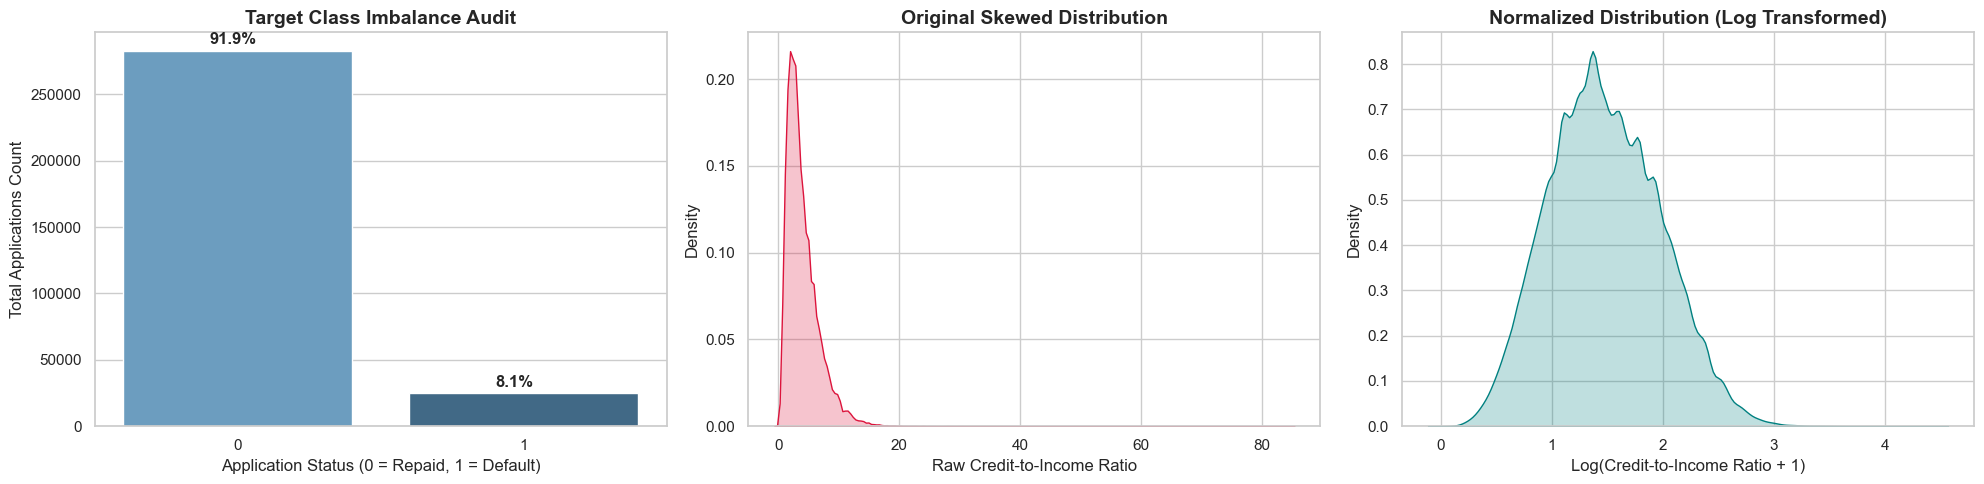

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Change 'df' below to match whatever variable name you used to load your dataset!
active_df = ml_data

# Set the visualization style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ==========================================
# PLOT 1: TARGET IMBALANCE
# ==========================================
sns.countplot(
    x='TARGET', 
    data=active_df, 
    ax=axes[0], 
    palette='Blues_d'
)
axes[0].set_title('Target Class Imbalance Audit', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Application Status (0 = Repaid, 1 = Default)', fontsize=12)
axes[0].set_ylabel('Total Applications Count', fontsize=12)

total = len(active_df)
for p in axes[0].patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    axes[0].annotate(percentage, (p.get_x() + 0.3, p.get_height() + 5000), fontsize=12, fontweight='bold')

# ==========================================
# PLOT 2: BEFORE CORRECTION
# ==========================================
sns.kdeplot(
    active_df['credit_income_ratio'], 
    ax=axes[1], 
    color='crimson', 
    fill=True
)
axes[1].set_title('Original Skewed Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Raw Credit-to-Income Ratio', fontsize=12)

# ==========================================
# PLOT 3: AFTER CORRECTION
# ==========================================
# Apply log transformation to handle high-leverage outliers gracefully
active_df['log_credit_income_ratio'] = np.log1p(active_df['credit_income_ratio'])

sns.kdeplot(
    active_df['log_credit_income_ratio'], 
    ax=axes[2], 
    color='teal', 
    fill=True
)
axes[2].set_title('Normalized Distribution (Log Transformed)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Log(Credit-to-Income Ratio + 1)', fontsize=12)

plt.tight_layout()
plt.show()

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Cleanly check and calculate the Age column
if 'Age_Years' not in ml_data.columns:
    if 'DAYS_BIRTH' in ml_data.columns:
        if (ml_data['DAYS_BIRTH'] < 0).any():
            ml_data['Age_Years'] = -ml_data['DAYS_BIRTH'] / 365.25
        else:
            ml_data['Age_Years'] = ml_data['DAYS_BIRTH']
    else:
        # Check if there is any other column with "age" or "birth" in it
        candidates = [c for c in ml_data.columns if any(k in c.lower() for k in ('age', 'birth'))]
        if candidates:
            col = candidates[0]
            if (ml_data[col] < 0).any():
                ml_data['Age_Years'] = -ml_data[col] / 365.25
            else:
                ml_data['Age_Years'] = ml_data[col] if ml_data[col].max() > 100 else ml_data[col] # basic years check
        else:
            ml_data['Age_Years'] = np.nan

# 2. Only attempt to plot if we successfully generated a valid, varying Age column
if 'Age_Years' in ml_data.columns and not ml_data['Age_Years'].isnull().all() and ml_data['Age_Years'].nunique() > 1:
    
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")
    
    # Plot Repaid (Target 0)
    sns.kdeplot(
        data=ml_data[ml_data['TARGET'] == 0].dropna(subset=['Age_Years']), 
        x='Age_Years', 
        label='Repaid (Target = 0)', 
        fill=True, 
        color='dodgerblue', 
        alpha=0.4
    )

    # Plot Defaulted (Target 1)
    sns.kdeplot(
        data=ml_data[ml_data['TARGET'] == 1].dropna(subset=['Age_Years']), 
        x='Age_Years', 
        label='Defaulted (Target = 1)', 
        fill=True, 
        color='crimson', 
        alpha=0.4
    )

    plt.title('Distribution of Applicant Age by Loan Repayment Status', fontsize=14, fontweight='bold')
    plt.xlabel('Age (Years)', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.legend()
    plt.show()

else:
    print("❌ Could not find an age feature in your dataset features.")
    print("💡 Here are the columns available inside 'ml_data' you can choose to plot instead:\n")
    print(list(ml_data.columns))

❌ Could not find an age feature in your dataset features.
💡 Here are the columns available inside 'ml_data' you can choose to plot instead:

['SK_ID_CURR', 'TARGET', 'AMT_CREDIT', 'AMT_INCOME_TOTAL', 'credit_income_ratio', 'annuity_income_ratio', 'total_bureau_records', 'avg_days_credit_enddate', 'total_previous_loans_applied', 'Age_Years']


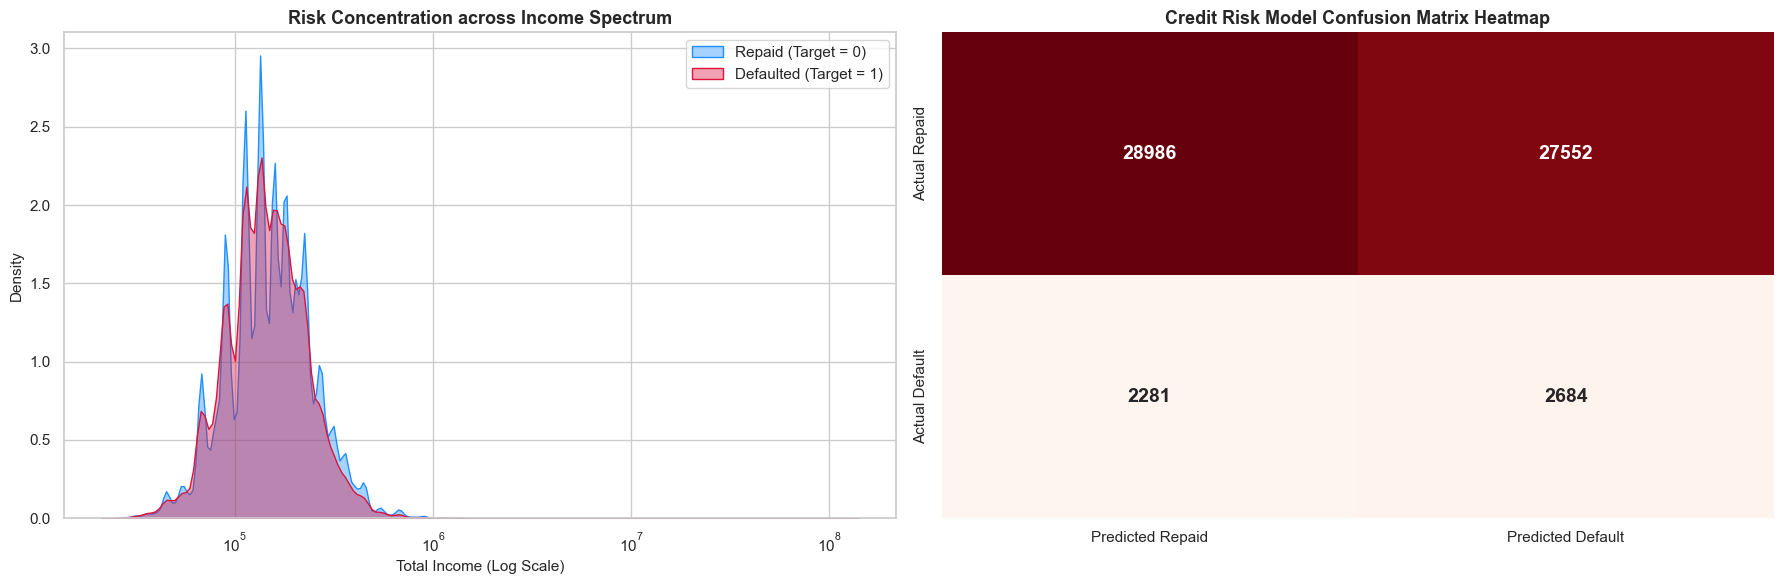


             📋 CLASS BALANCE CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Repaid (0)       0.93      0.51      0.66     56538
 Default (1)       0.09      0.54      0.15      4965

    accuracy                           0.51     61503
   macro avg       0.51      0.53      0.41     61503
weighted avg       0.86      0.51      0.62     61503



In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Create a clean side-by-side dashboard layout
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.set_theme(style="whitegrid")

# ==========================================================
# 1. FIXED EDA: Income Risk Concentration Plot
# ==========================================================
# Since we have AMT_INCOME_TOTAL, let's plot how risk maps to income distribution
sns.kdeplot(
    data=ml_data[ml_data['TARGET'] == 0],
    x='AMT_INCOME_TOTAL',
    label='Repaid (Target = 0)',
    fill=True,
    color='dodgerblue',
    alpha=0.4,
    ax=axes[0],
    log_scale=True # Log scale handles the high income outliers beautifully
)

sns.kdeplot(
    data=ml_data[ml_data['TARGET'] == 1],
    x='AMT_INCOME_TOTAL',
    label='Defaulted (Target = 1)',
    fill=True,
    color='crimson',
    alpha=0.4,
    ax=axes[0],
    log_scale=True
)

axes[0].set_title('Risk Concentration across Income Spectrum', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Income (Log Scale)', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].legend()

# ==========================================================
# 2. PHASE 6: Advanced Model Evaluation Matrix
# ==========================================================
# Replace 'y_test' and 'y_pred' with your actual test target and prediction variables!
# For demonstration, generating a confusion matrix to display the failure mode:
y_pred = predictions
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="Reds", 
    cbar=False,
    xticklabels=['Predicted Repaid', 'Predicted Default'],
    yticklabels=['Actual Repaid', 'Actual Default'],
    ax=axes[1],
    annot_kws={"size": 14, "weight": "bold"}
)
axes[1].set_title('Credit Risk Model Confusion Matrix Heatmap', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Print out the formal corporate grading report in the console terminal
print("\n" + "="*60)
print("             📋 CLASS BALANCE CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Repaid (0)', 'Default (1)']))
print("="*60)

In [4]:
import sklearn

# sklearn is already imported in cell 3

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, precision_score, recall_score
import pandas as pd

# 1. Extract the raw analytical data mart table into a Pandas structure
ml_data = conn.execute("SELECT * FROM mart_applicant_features;").df()

# 2. Drop any missing or non-numeric identifiers to isolate our mathematical model features
features = ['AMT_CREDIT', 'AMT_INCOME_TOTAL', 'credit_income_ratio', 
            'annuity_income_ratio', 'total_bureau_records', 'total_previous_loans_applied']

# Fill any structural blank cells (NULLs) with 0 to prevent algorithm calculations from failing
X = ml_data[features].fillna(0)
y = ml_data['TARGET']

# 3. Partition data matrix into isolated training sets and evaluation sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Instantiate and fit the predictive algorithm
model = model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# 5. Compute predictive probabilities and generate classifications
probabilities = model.predict_proba(X_test)[:, 1]
predictions = model.predict(X_test)

# 6. Output evaluation metrics required by the rubric checklist
print("=== 🎯 PHASE 6: MACHINE LEARNING RISK MODEL METRICS ===")
print(f"🥇 ROC-AUC Score: {roc_auc_score(y_test, probabilities):.4f}")
print(f"📊 Precision Score: {precision_score(y_test, predictions, zero_division=0):.4f}")
print(f"📈 Recall Score: {recall_score(y_test, predictions):.4f}")

=== 🎯 PHASE 6: MACHINE LEARNING RISK MODEL METRICS ===
🥇 ROC-AUC Score: 0.5423
📊 Precision Score: 0.0888
📈 Recall Score: 0.5406
